In [44]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *

In [45]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

In [3]:
data, data_train, _, _, _, _, _ = dataprep(data)

In [5]:
data = data.sort_values(by=['id', 'time'])

print(data.loc[(data.id==9)|(data.id==47), ['id', 'time', 'default_time']])

         id  time  default_time
1       9.0  25.0           0.0
1845    9.0  26.0           0.0
3738    9.0  27.0           0.0
5819    9.0  28.0           0.0
8080    9.0  29.0           0.0
...     ...   ...           ...
23579   9.0  36.0           0.0
25316   9.0  37.0           1.0
2      47.0  25.0           0.0
1846   47.0  26.0           0.0
3739   47.0  27.0           0.0

[16 rows x 3 columns]


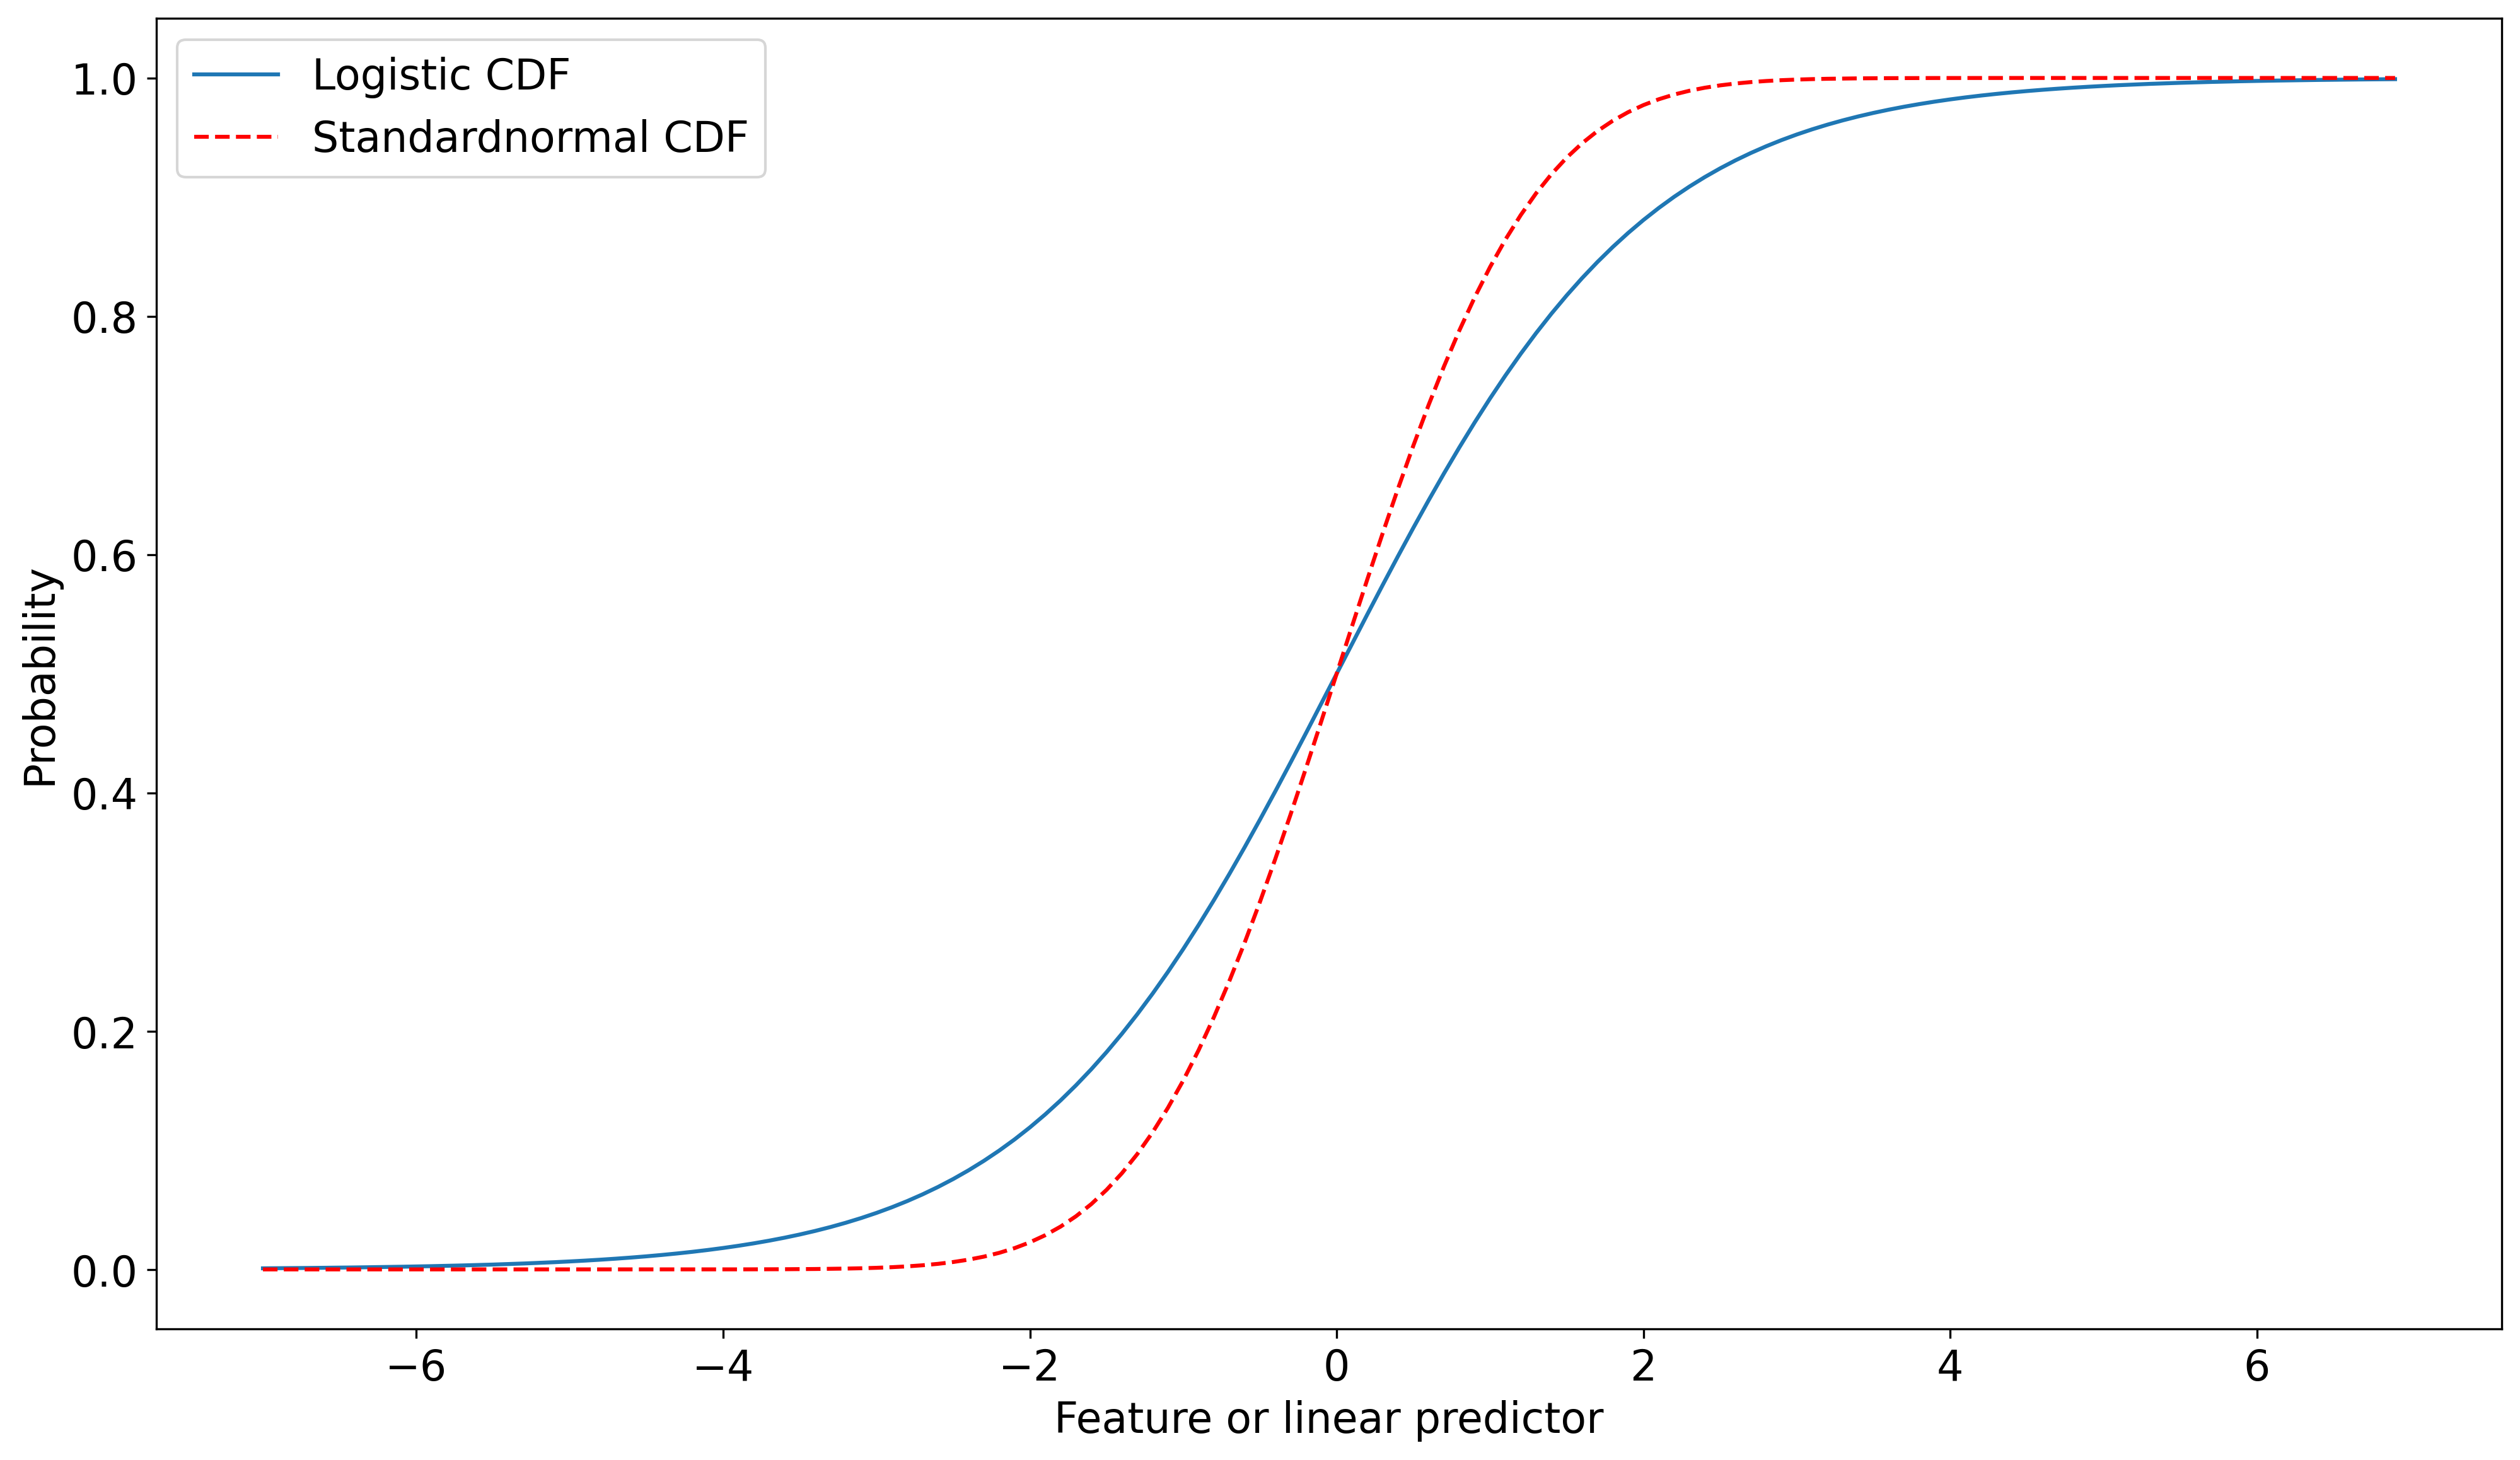

In [6]:
x=np.arange(-7, 7, 0.1)  
pd_time_logit=scipy.stats.logistic.cdf(x, 0, 1)  
pd_time_probit=scipy.stats.norm.cdf(x, 0, 1) 
plt.plot(x,pd_time_logit,label='Logistic CDF') 
plt.plot(x, pd_time_probit,color='red',label='Standardnormal CDF',linestyle='dashed') 
plt.xlabel('Feature or linear predictor')  
plt.ylabel('Probability')  
plt.legend(loc='best')  
plt.show() 


In [7]:
glm_logit=smf.glm('default_time~cep_time',family=sm.families.Binomial(),data=data).fit()  
print(glm_logit.summary())  

                 Generalized Linear Model Regression Results                  
Dep. Variable:           default_time   No. Observations:                59001
Model:                            GLM   Df Residuals:                    58999
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6869.7
Date:                Thu, 07 Aug 2025   Deviance:                       13739.
Time:                        11:55:33   Pearson chi2:                 5.89e+04
No. Iterations:                     7   Pseudo R-squ. (CS):          7.457e-05
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.6745      0.027   -138.129      0.0

In [8]:
data.loc[:,'const'] = 1  
y = data[['default_time']] 
X = data[['const', 'cep_time']] 
model_lr = sm.Logit(y,X,missing='drop').fit()  
print(model_lr.summary()) 

Optimization terminated successfully.
         Current function value: 0.116433
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:           default_time   No. Observations:                59001
Model:                          Logit   Df Residuals:                    58999
Method:                           MLE   Df Model:                            1
Date:                Thu, 07 Aug 2025   Pseudo R-squ.:               0.0003201
Time:                        14:44:47   Log-Likelihood:                -6869.7
converged:                       True   LL-Null:                       -6871.9
Covariance Type:            nonrobust   LLR p-value:                   0.03594
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.6745      0.027   -138.129      0.000      -3.727      -3.622
cep_time      -0.3047      0.

In [9]:
PD_logit_model = pd.DataFrame(glm_logit.fittedvalues,columns=['PD_logit_model'])

In [11]:
glm_probit = smf.glm('default_time ~ cep_time',family = sm.families.Binomial(sm.families.links.probit()), data=data).fit()  
print(glm_probit.summary()) 

                 Generalized Linear Model Regression Results                  
Dep. Variable:           default_time   No. Observations:                59001
Model:                            GLM   Df Residuals:                    58999
Model Family:                Binomial   Df Model:                            1
Link Function:                 probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6869.1
Date:                Thu, 07 Aug 2025   Deviance:                       13738.
Time:                        14:52:33   Pearson chi2:                 5.89e+04
No. Iterations:                     9   Pseudo R-squ. (CS):          9.361e-05
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.9653      0.011   -177.142      0.0

In [12]:
PD_probit_model = pd.DataFrame(glm_probit.fittedvalues,columns=['PD_probit_model'])

In [13]:
data2 = pd.merge(data['default_time'],PD_logit_model,right_index=True,left_index=True)  
data3 = pd.merge(data2,PD_probit_model,right_index=True,left_index=True)  
print(data3.describe().round(decimals=3)) 

       default_time  PD_logit_model  PD_probit_model
count     59001.000       59001.000        59001.000
mean          0.025           0.025            0.025
std           0.156           0.002            0.002
min           0.000           0.019            0.017
25%           0.000           0.025            0.025
50%           0.000           0.025            0.025
75%           0.000           0.025            0.025
max           1.000           0.100            0.124


In [14]:
print(data3.corr(method='pearson').round(decimals=3))

                 default_time  PD_logit_model  PD_probit_model
default_time            1.000           0.004            0.004
PD_logit_model          0.004           1.000            1.000
PD_probit_model         0.004           1.000            1.000


In [15]:
data2 = pd.merge(data['cep_time'], PD_logit_model, right_index=True, left_index=True)  
data2.loc[:,'linear_predictor'] = -3.7049 - np.log(((1-0.05)/0.05) * (0.0244/(1-0.0244))) - 0.6700 * data2.cep_time
data2.loc[:,'PD_logit_model_target'] = np.exp(data2.linear_predictor)/ (1+np.exp(data2.linear_predictor)) 
print(data2[['PD_logit_model','PD_logit_model_target']].describe().round(decimals=3)) 


       PD_logit_model  PD_logit_model_target
count       59001.000              59001.000
mean            0.025                  0.050
std             0.002                  0.012
min             0.019                  0.028
25%             0.025                  0.049
50%             0.025                  0.049
75%             0.025                  0.050
max             0.100                  0.574


In [16]:
model_lr2 = smf.glm('default_time ~ equity_time', family=sm.families.Binomial(), data=data).fit()  
print(model_lr2.summary()) 

                 Generalized Linear Model Regression Results                  
Dep. Variable:           default_time   No. Observations:                59001
Model:                            GLM   Df Residuals:                    58999
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6772.4
Date:                Thu, 07 Aug 2025   Deviance:                       13545.
Time:                        15:01:07   Pearson chi2:                 5.52e+04
No. Iterations:                     7   Pseudo R-squ. (CS):           0.003367
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -3.5652      0.027   -130.181      

In [17]:
model_lr3 = smf.glm('default_time ~ cep_time + equity_time', family=sm.families.Binomial(),  data=data).fit()  
print(model_lr3.summary()) 

                 Generalized Linear Model Regression Results                  
Dep. Variable:           default_time   No. Observations:                59001
Model:                            GLM   Df Residuals:                    58998
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6596.7
Date:                Thu, 07 Aug 2025   Deviance:                       13193.
Time:                        15:05:34   Pearson chi2:                 5.87e+04
No. Iterations:                     7   Pseudo R-squ. (CS):           0.009285
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -3.3187      0.028   -118.935      

In [18]:
PD_logit_model = pd.DataFrame(model_lr3.fittedvalues, columns=['PD_logit_model']) 
data2 = pd.merge(data[['default_time','time']], PD_logit_model, right_index=True,  left_index=True)

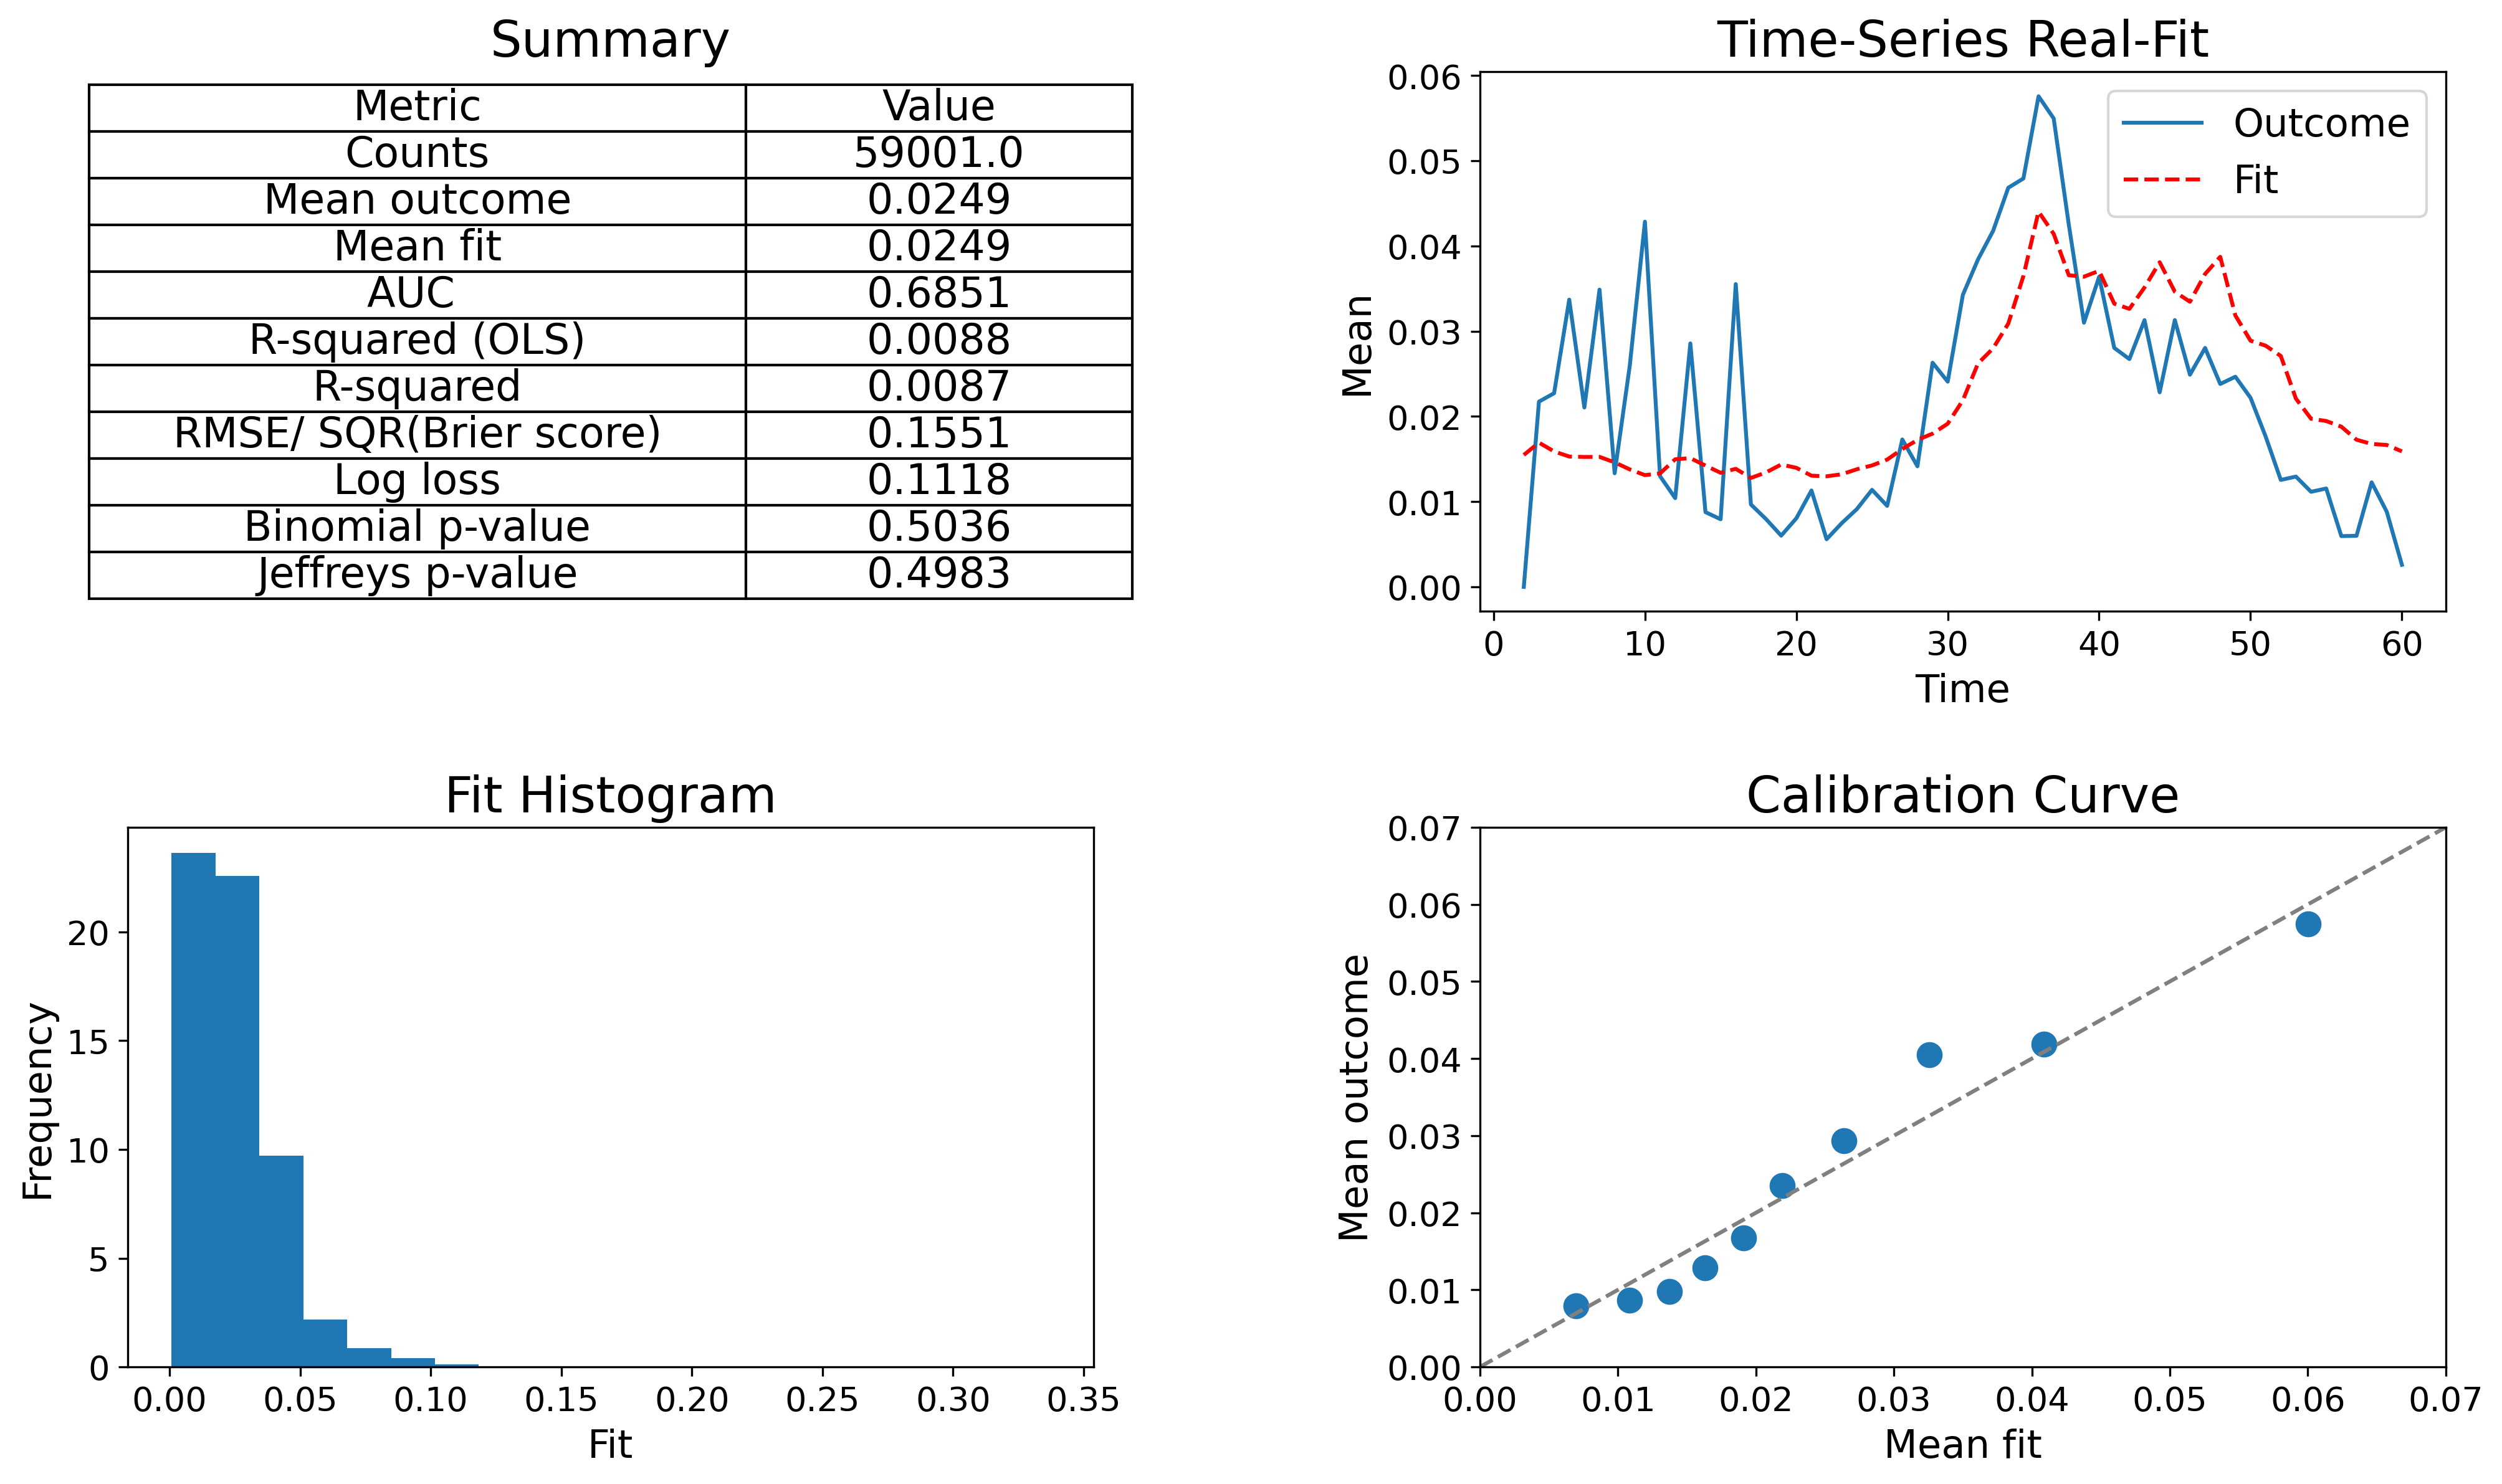

In [19]:
validation(data2.PD_logit_model,data2.default_time,data2.time)

In [20]:
model_lr4 = smf.glm('default_time ~ cep_time + equity_time + interest_rate_time +  FICO_orig_time + gdp_time + PCA1_1 + PCA2_1 + PCA3_1 + PCA4_1 + PCA5_1 + cluster_1',  family = sm.families.Binomial(), data=data).fit()  
print(model_lr4.summary()) 

                 Generalized Linear Model Regression Results                  
Dep. Variable:           default_time   No. Observations:                59001
Model:                            GLM   Df Residuals:                    58989
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6409.2
Date:                Thu, 07 Aug 2025   Deviance:                       12818.
Time:                        15:08:35   Pearson chi2:                 5.40e+04
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01556
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -2.4363      0

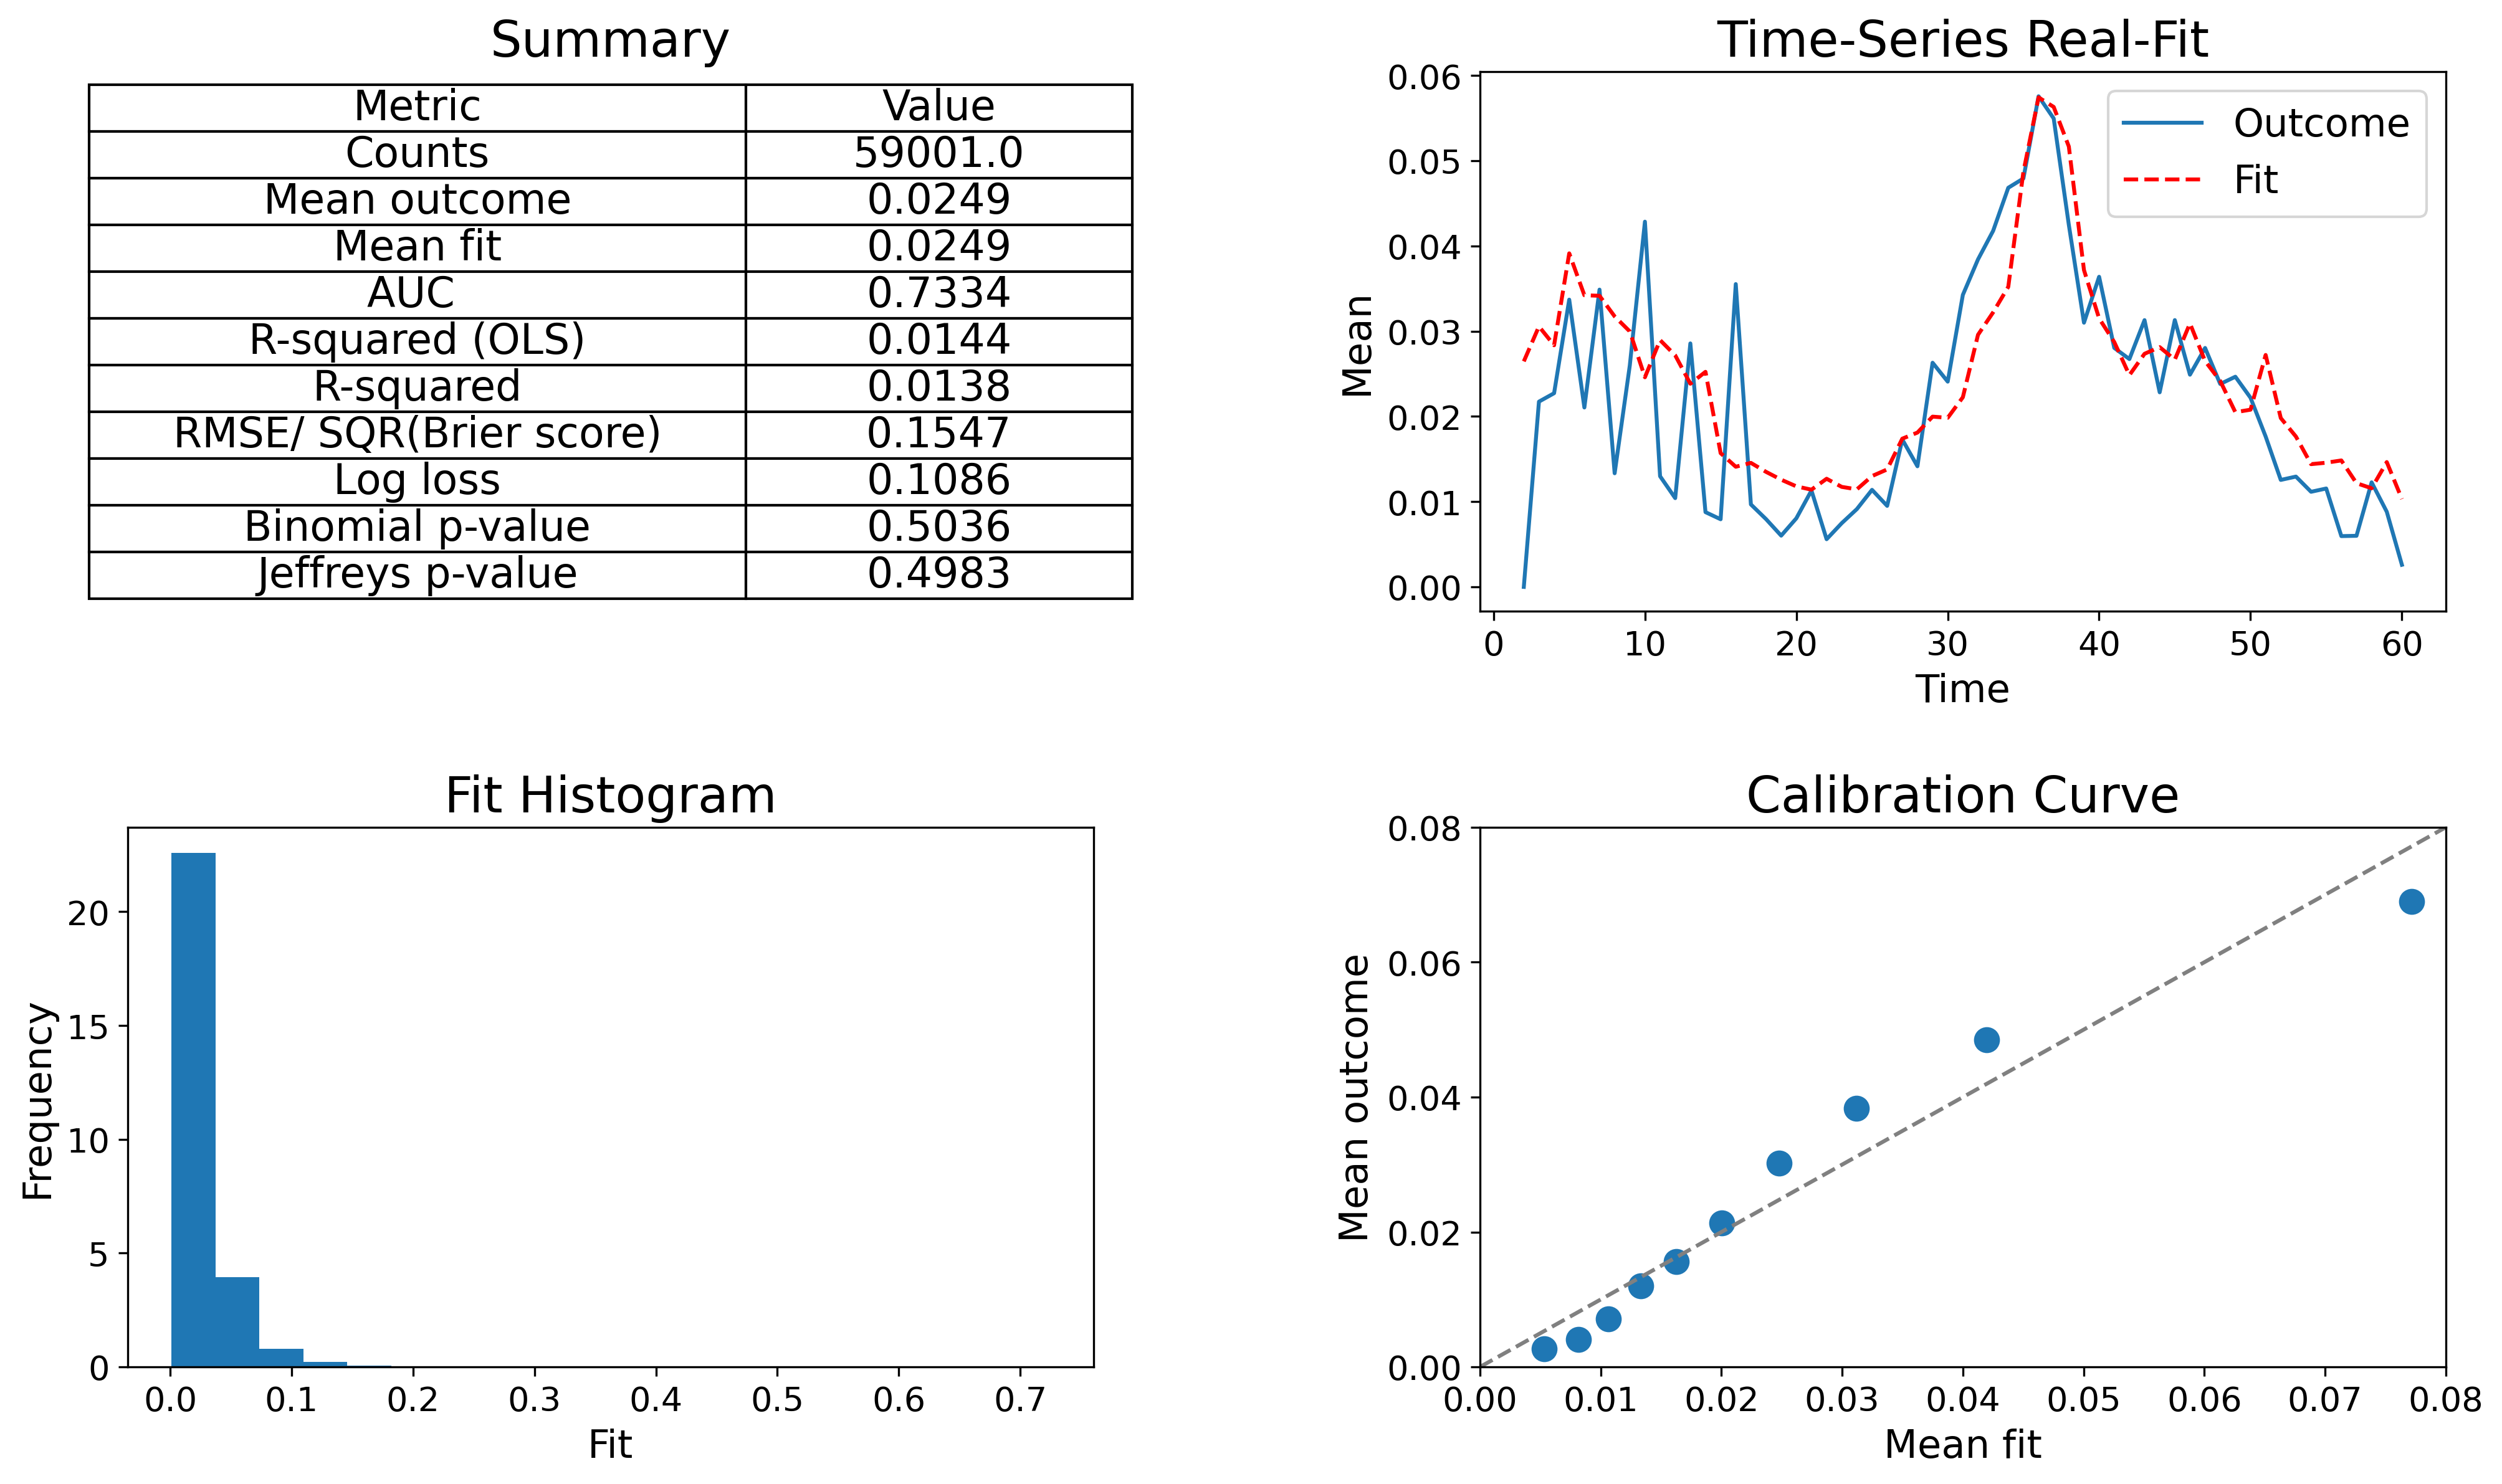

In [21]:
PD_logit_model = pd.DataFrame(model_lr4.fittedvalues, columns=['PD_logit_model'])  
data2 = pd.merge(data[['default_time','time']], PD_logit_model, right_index=True,  left_index=True)  
validation(data2.PD_logit_model, data2.default_time, data2.time)  

In [22]:
model_lr4 = smf.glm('default_time ~ cep_time + equity_time + interest_rate_time +  FICO_orig_time + gdp_time + PCA1_1 + PCA2_1 + PCA3_1 + PCA4_1 + PCA5_1 + cluster_1',  family = sm.families.Binomial(), data=data).fit()  
print(model_lr4.summary()) 

                 Generalized Linear Model Regression Results                  
Dep. Variable:           default_time   No. Observations:                59001
Model:                            GLM   Df Residuals:                    58989
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6409.2
Date:                Thu, 07 Aug 2025   Deviance:                       12818.
Time:                        15:10:56   Pearson chi2:                 5.40e+04
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01556
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -2.4363      0

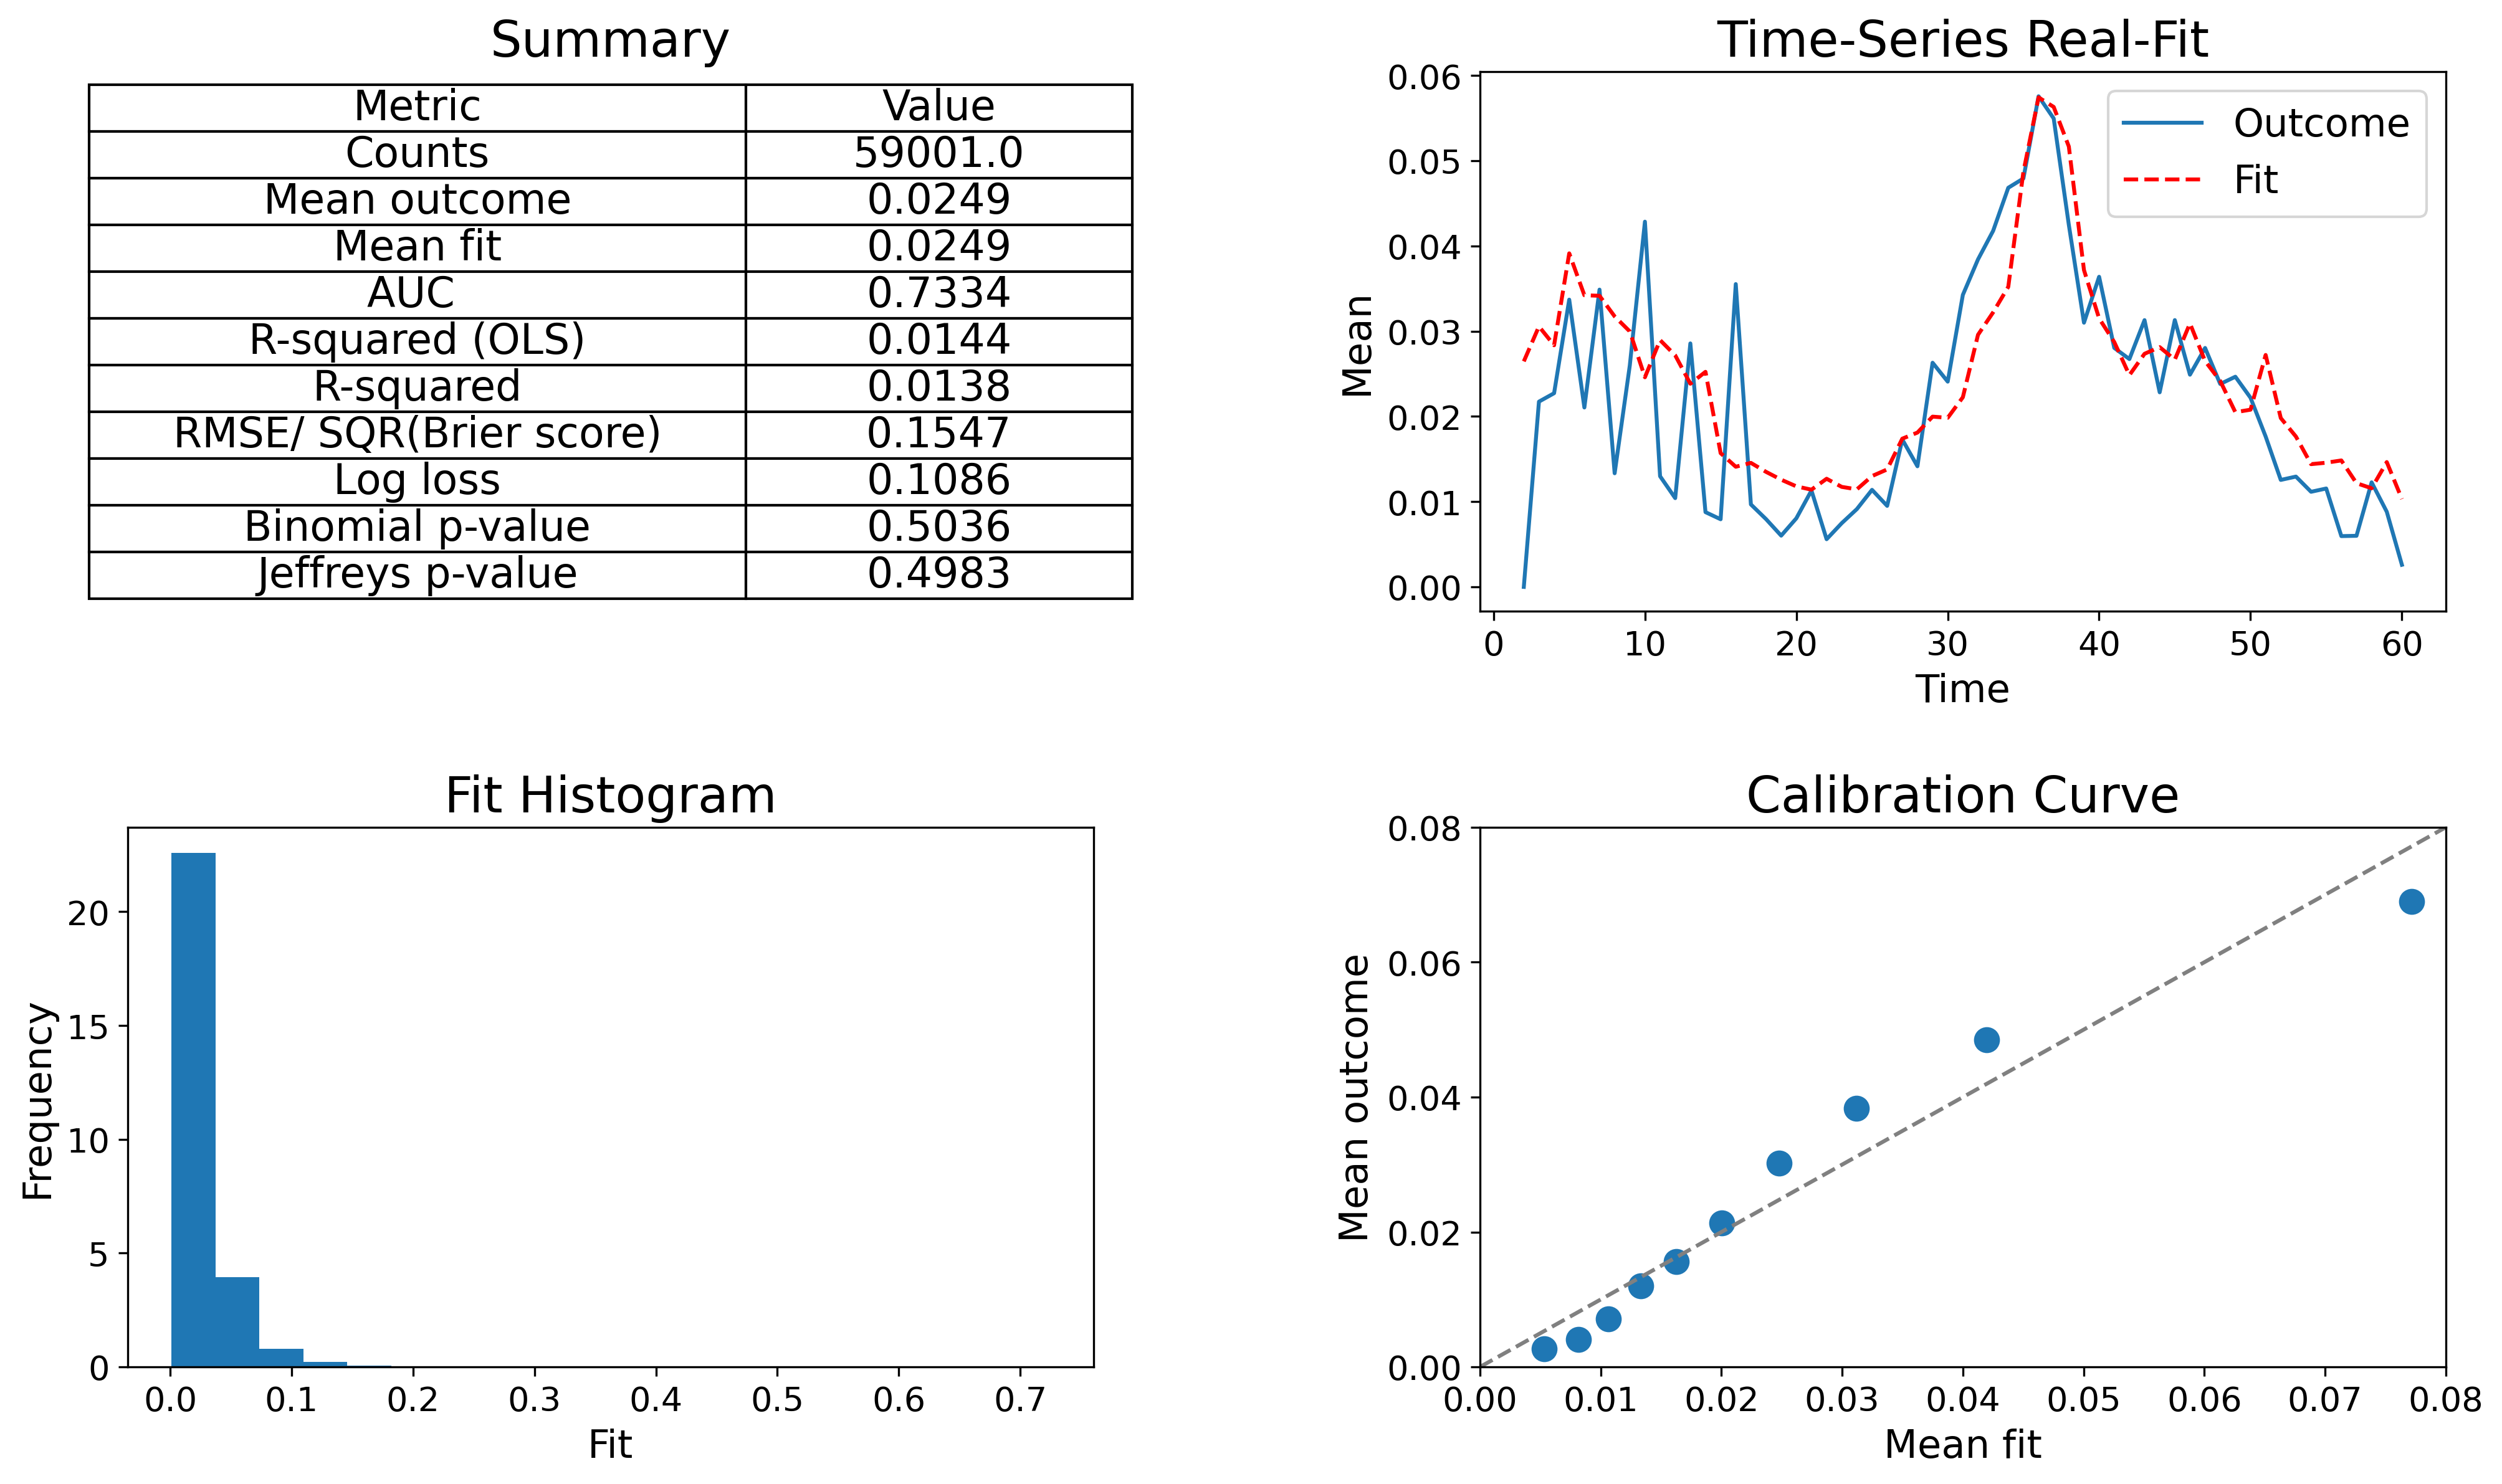

In [23]:
PD_logit_model = pd.DataFrame(model_lr4.fittedvalues, columns=['PD_logit_model'])  
data2 = pd.merge(data[['default_time','time']], PD_logit_model, right_index=True,  left_index=True)  
validation(data2.PD_logit_model, data2.default_time, data2.time) 

In [25]:
data['const'] = 1 
y = data[['default_time']]  
X_const = data[['const', 'cep_time', 'equity_time', 'interest_rate_time', 'FICO_orig_time',  'gdp_time', 'PCA1_1', 'PCA2_1', 'PCA3_1', 'PCA4_1', 'PCA5_1', 'cluster_1']]  
model_lr4_SM = sm.Logit(y,X_const).fit()  
print(model_lr4_SM.summary())  

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data). The types seen weredefault_time    float64
dtype: object and const                   int64
cep_time              float64
equity_time           float64
interest_rate_time    float64
FICO_orig_time        float64
                       ...   
PCA2_1                float64
PCA3_1                float64
PCA4_1                float64
PCA5_1                float64
cluster_1              object
Length: 12, dtype: object. The data was
       default_time
0               0.0
1844            0.0
3737            0.0
5818            0.0
8079            0.0
...             ...
45971           0.0
46805           0.0
47620           0.0
48414           0.0
49185           0.0

[59001 rows x 1 columns]
and
        const  cep_time  equity_time  interest_rate_time  FICO_orig_time  \
0          1 -0.002785     0.660890              10.500           587.0   
1844       1 -0.002842     0.659928              10.5

In [26]:
PD_logit_model = pd.DataFrame(1/(1+exp(-model_lr4_SM.fittedvalues)), columns=['PD_logit_model']) 
data2 = pd.merge(data[['default_time','time']], PD_logit_model, right_index=True,  left_index=True)
validation(data2.PD_logit_model, data2.default_time, data2.time) 

NameError: name 'model_lr4_SM' is not defined

In [27]:
y = data[['default_time']] 
X = data[['cep_time', 'equity_time', 'interest_rate_time', 'FICO_orig_time', 'gdp_time', 'PCA1_1', 'PCA2_1', 'PCA3_1', 'PCA4_1', 'PCA5_1', 'cluster_1']]  
model_lr4_SL = LogisticRegression(penalty='none', fit_intercept=True, solver='newton-cg',  tol =1e-15, max_iter=10000)  
model_lr4_SL.fit(X, y)  
print('Coefficients:', model_lr4_SL.coef_.round(decimals=4)) 
print('Intercept:', model_lr4_SL.intercept_.round(decimals=4))

Coefficients: [[ 2.5349 -2.2053  0.1661 -0.0033 -0.0652  0.0107 -0.0034  0.0094  0.0151
   0.0485 -0.0148]]
Intercept: [-2.4363]


In [36]:
data, data_train, data_test, X_train_scaled, X_test_scaled, y_train, y_test = dataprep(data, depvar='default_time', splitvar='time', threshold=26)  
data_test = data_test.query('time <=40').copy()

KeyError: "['PCA1_1', 'PCA2_1', 'PCA3_1', 'PCA4_1', 'PCA5_1'] not in index"

In [32]:
print('Observations data_train:', len(data_train)) 
print('Observations data_test:', len(data_test)) 
print('Default rate train data:', data_train[['default_time']].mean().round(4))  
print('Default rate test data:', data_test[['default_time']].mean().round(4))

Observations data_train: 12702
Observations data_test: 27368
Default rate train data: default_time    0.0104
dtype: float64
Default rate test data: default_time    0.0355
dtype: float64


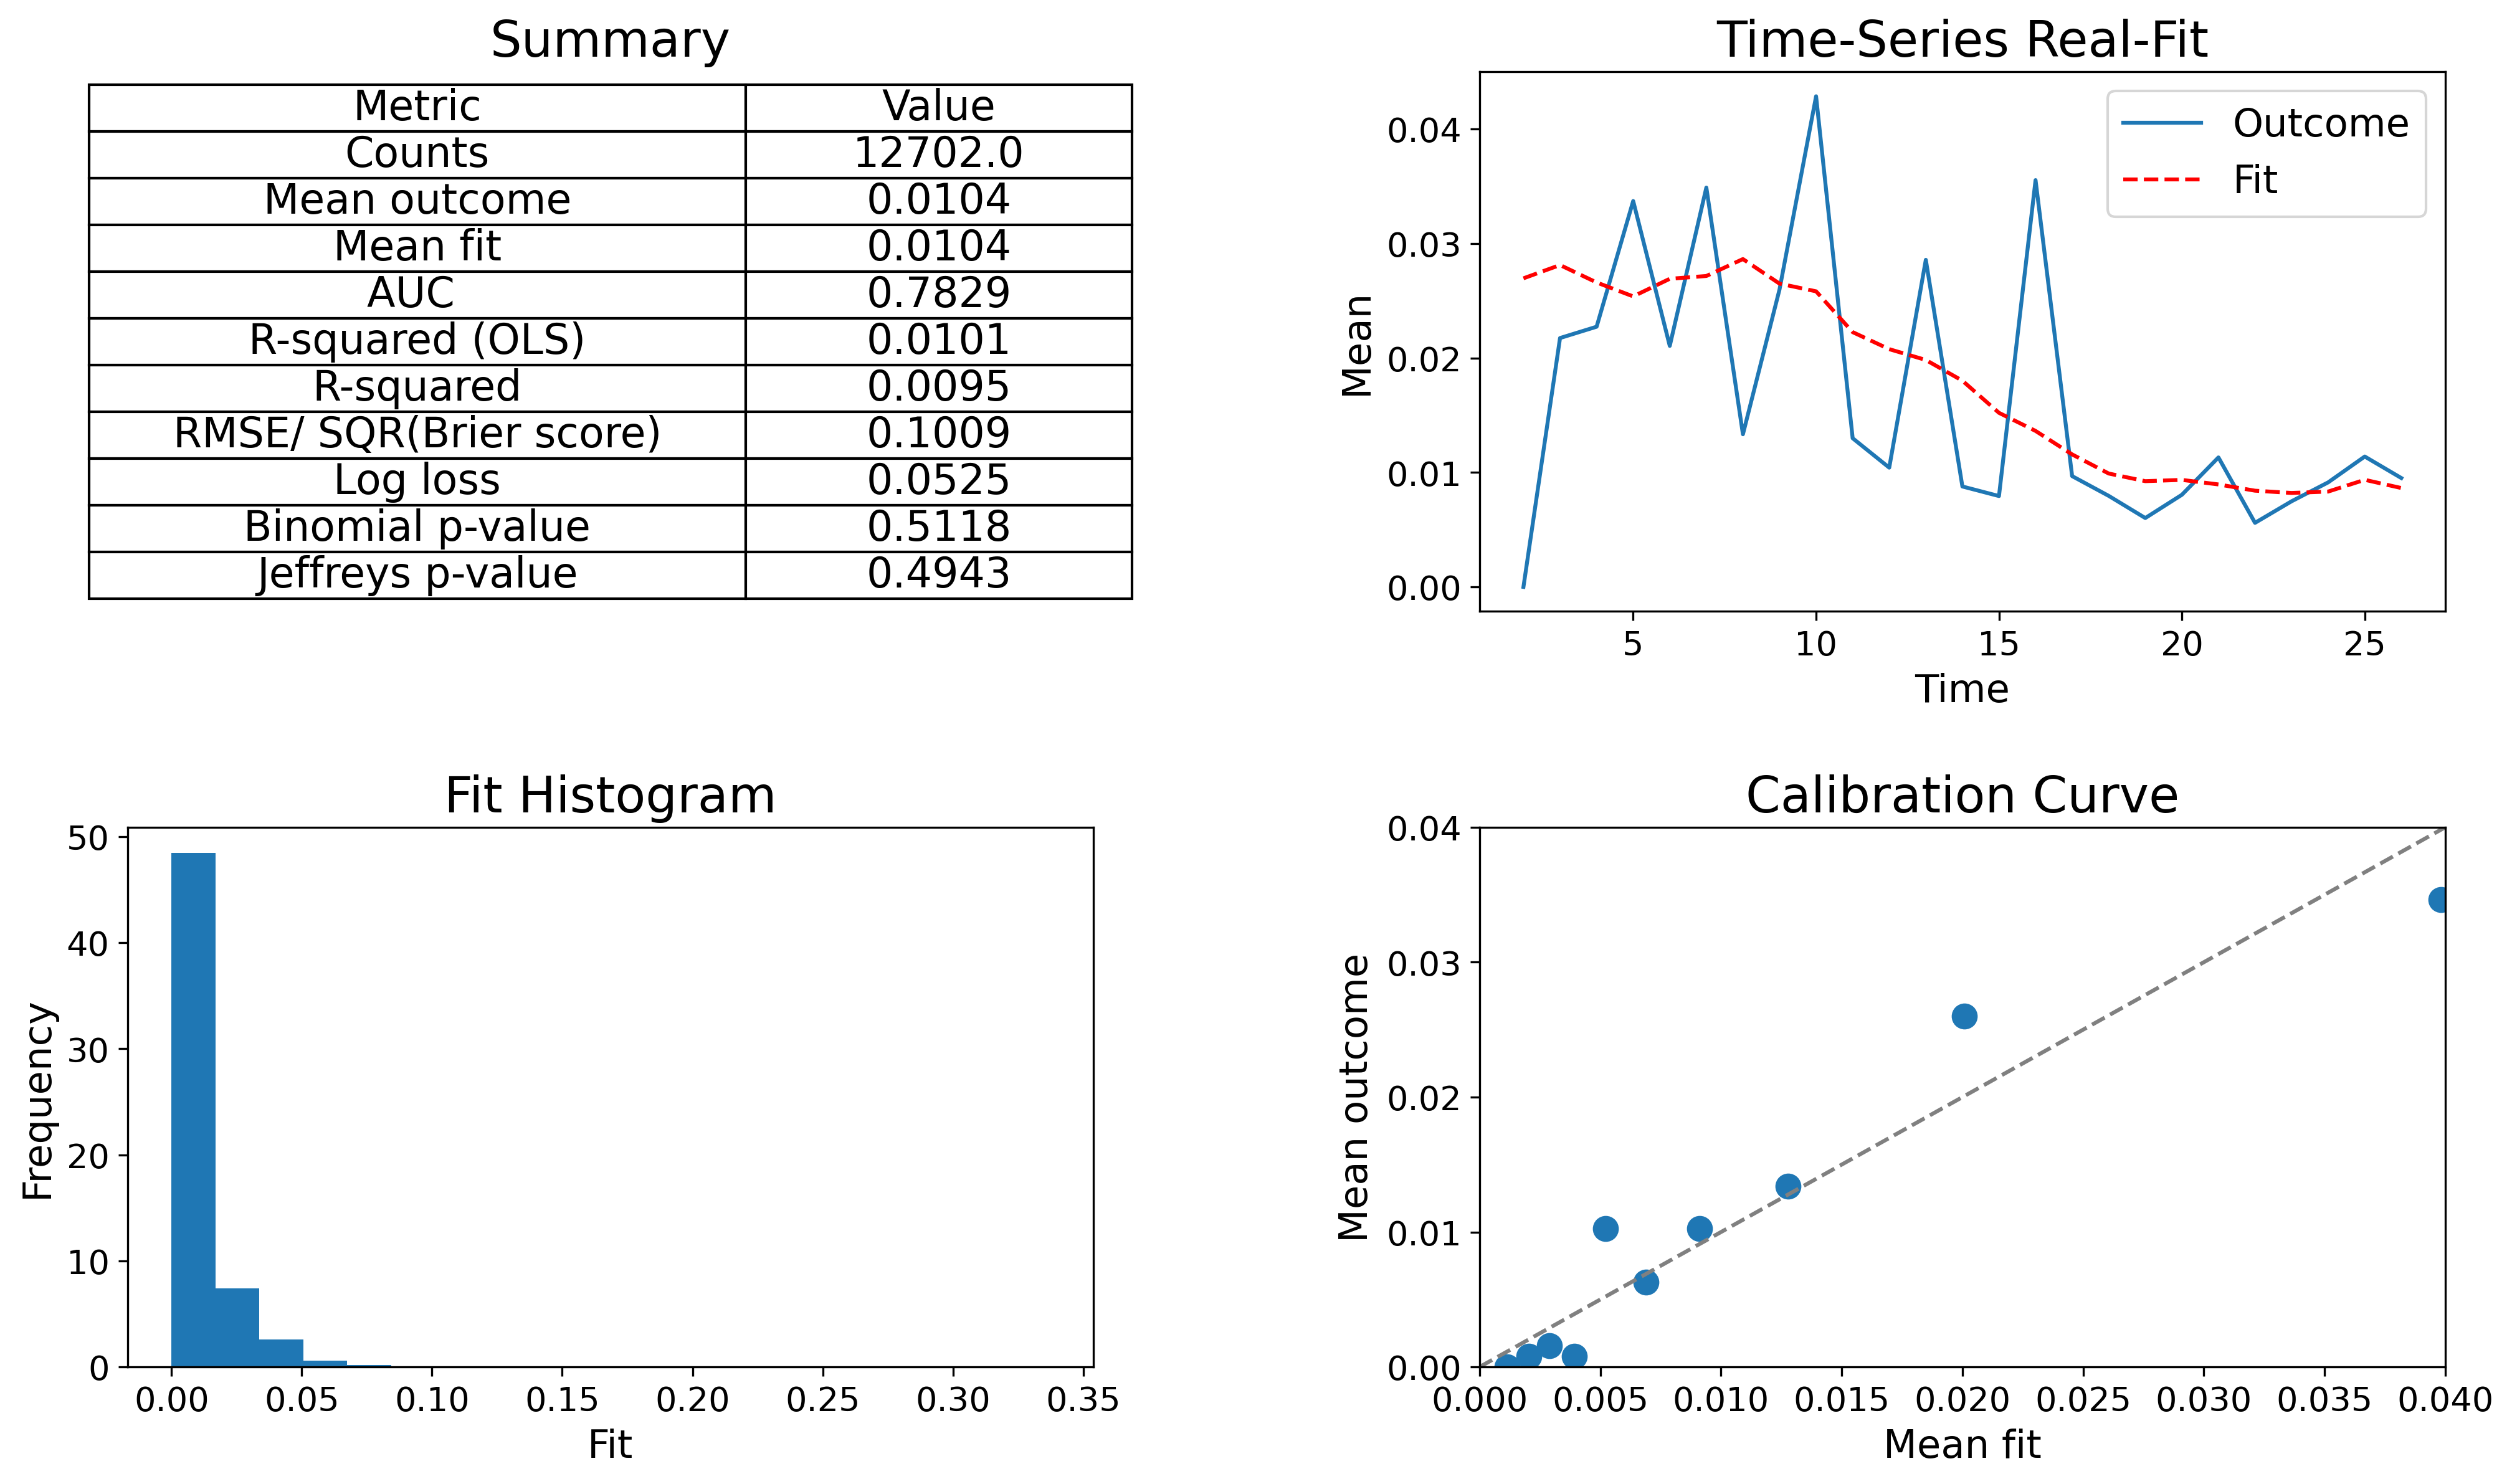

In [46]:
data, data_train, data_test, X_train_scaled, X_test_scaled, y_train, y_test = dataprep(data  , depvar='default_time', splitvar='time', threshold=26)  
data_test = data_test.query('time <=40').copy()  
model_lr4_train = smf.glm('default_time ~ cep_time + equity_time + interest_rate_time +  FICO_orig_time + gdp_time + cluster_1',  family = sm.families.Binomial(), data=data_train).fit()
PD_train = pd.DataFrame(model_lr4_train.predict(data_train), columns = ['PD_train'])  
PD_train = pd.concat([data_train[['default_time','time']], PD_train], axis=1).dropna() 
validation(PD_train.PD_train, PD_train.default_time, PD_train.time)


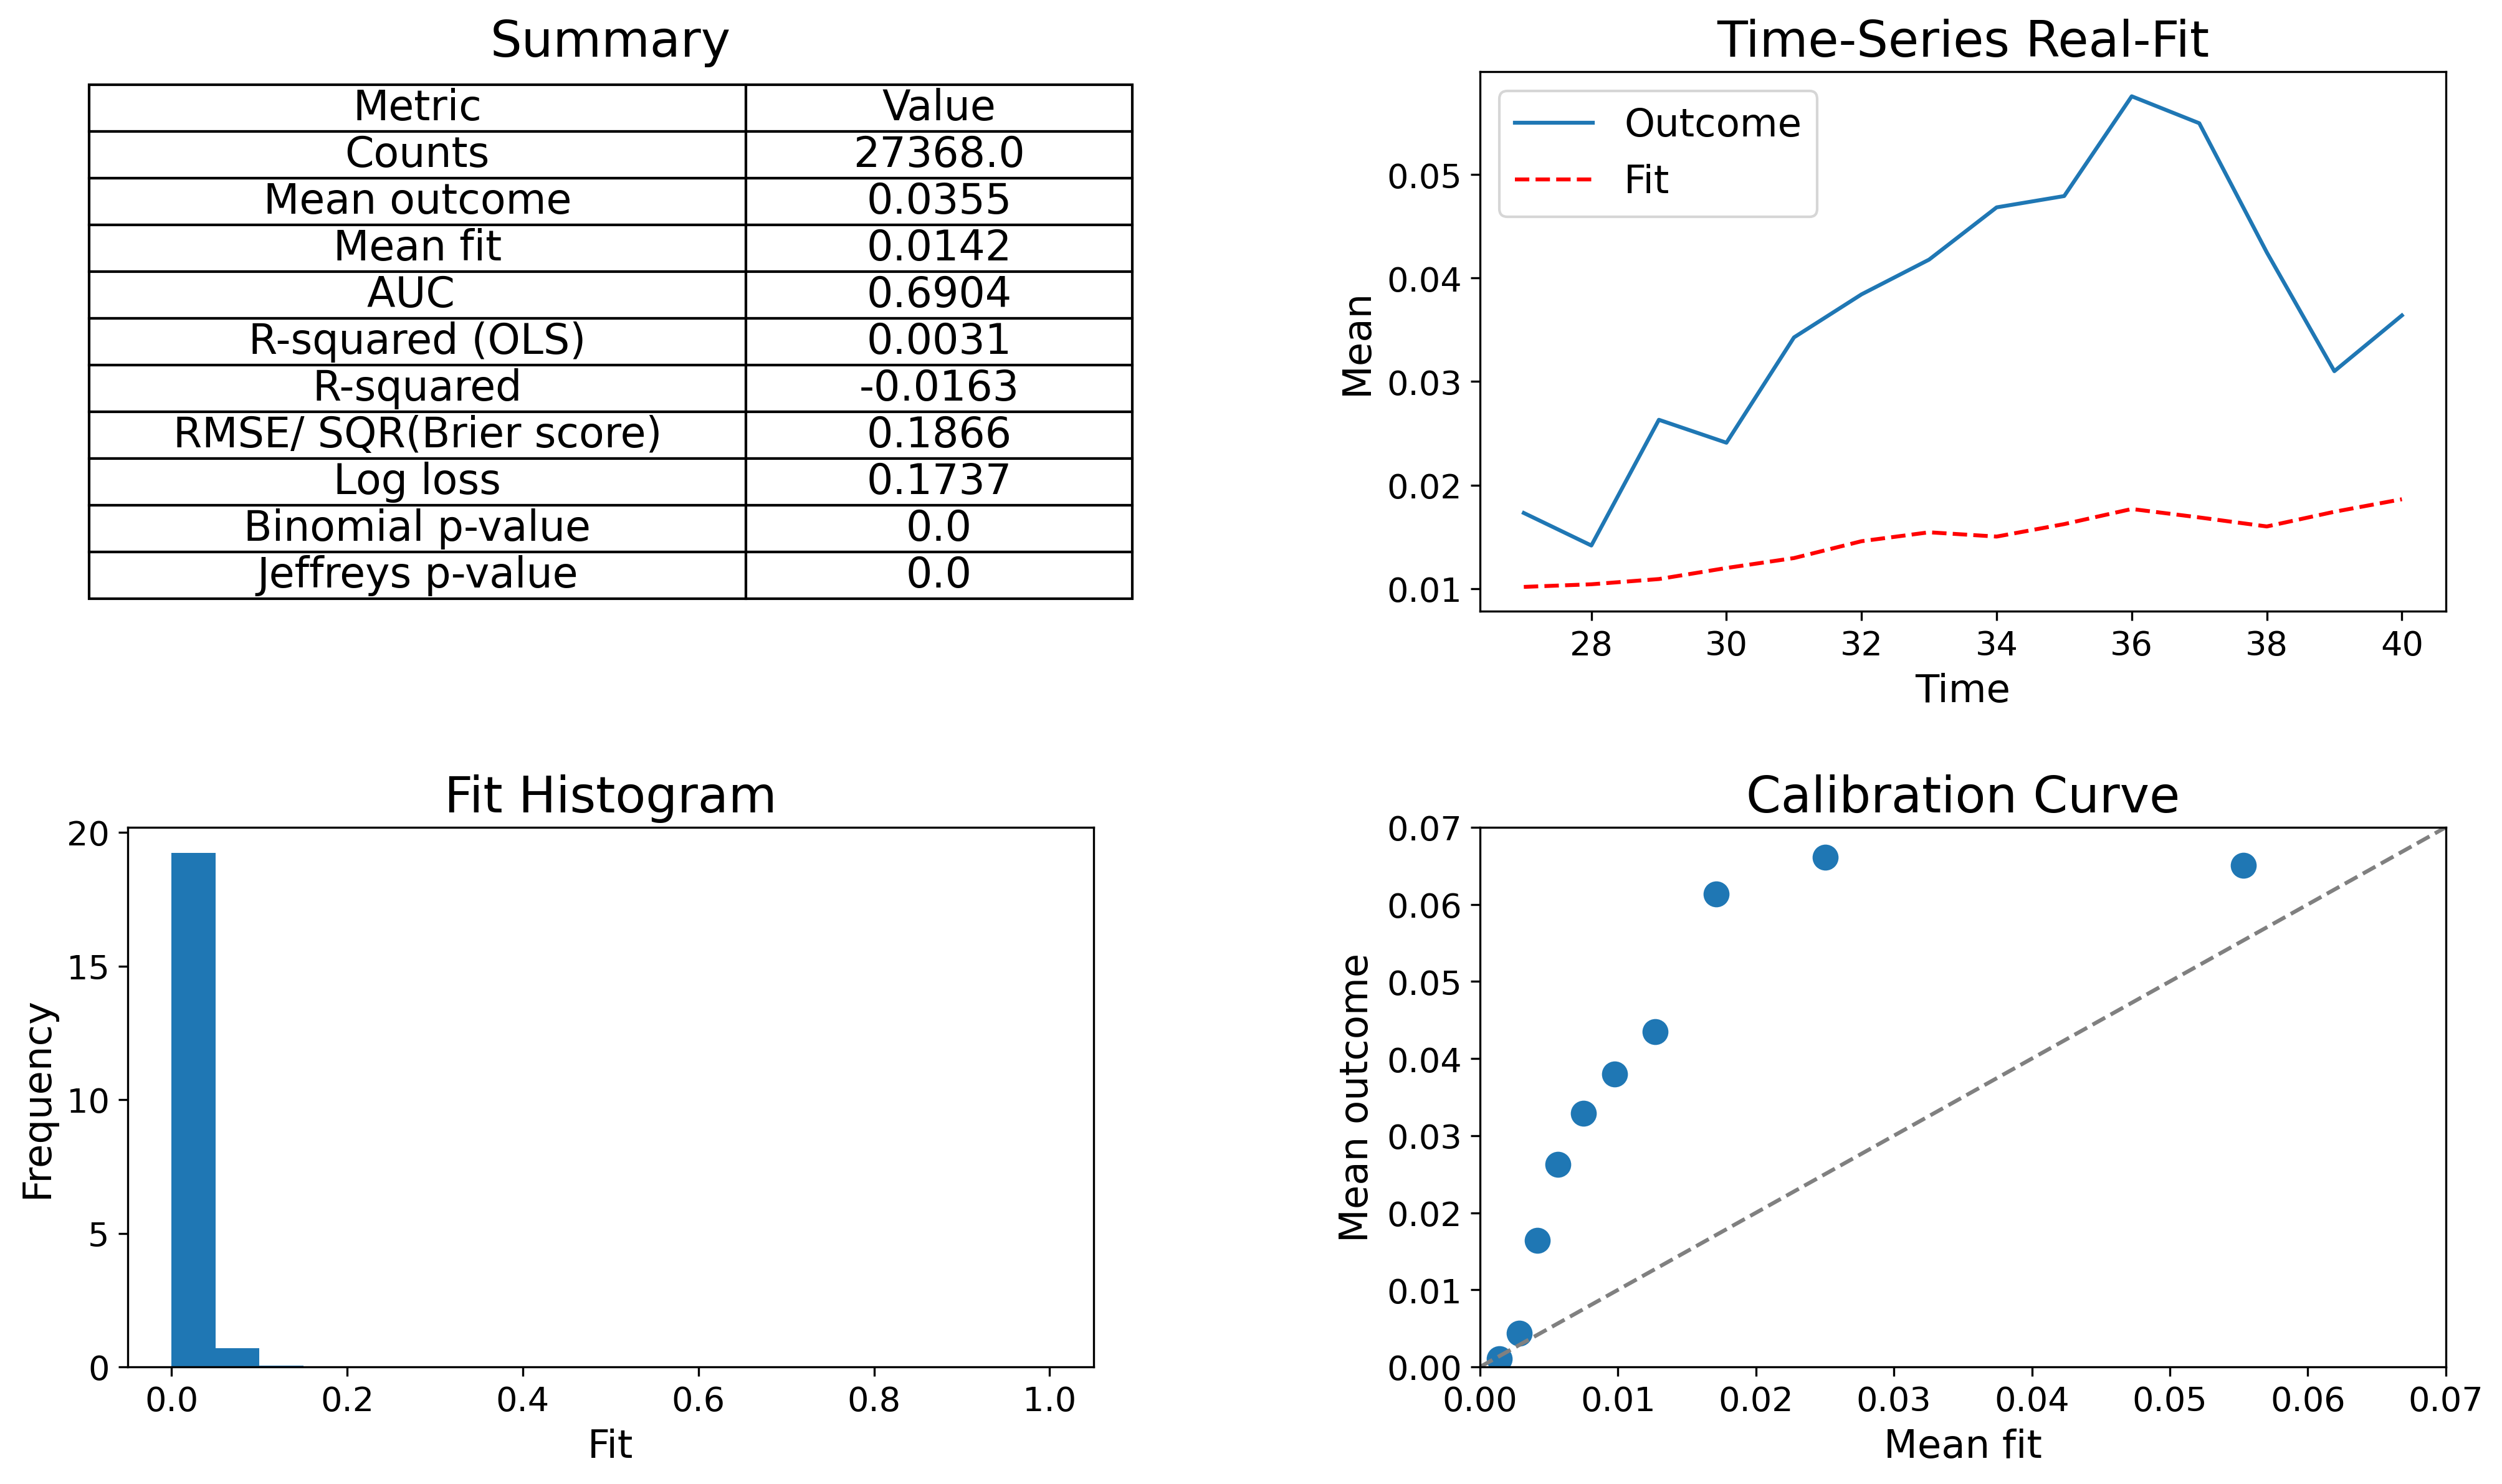

In [48]:
PD_test = pd.DataFrame(model_lr4_train.predict(data_test), columns = ['PD_test'])  
PD_test = pd.concat([data_test[['default_time','time']], PD_test],axis=1).dropna()  
validation(PD_test.PD_test, PD_test.default_time, PD_test.time) 


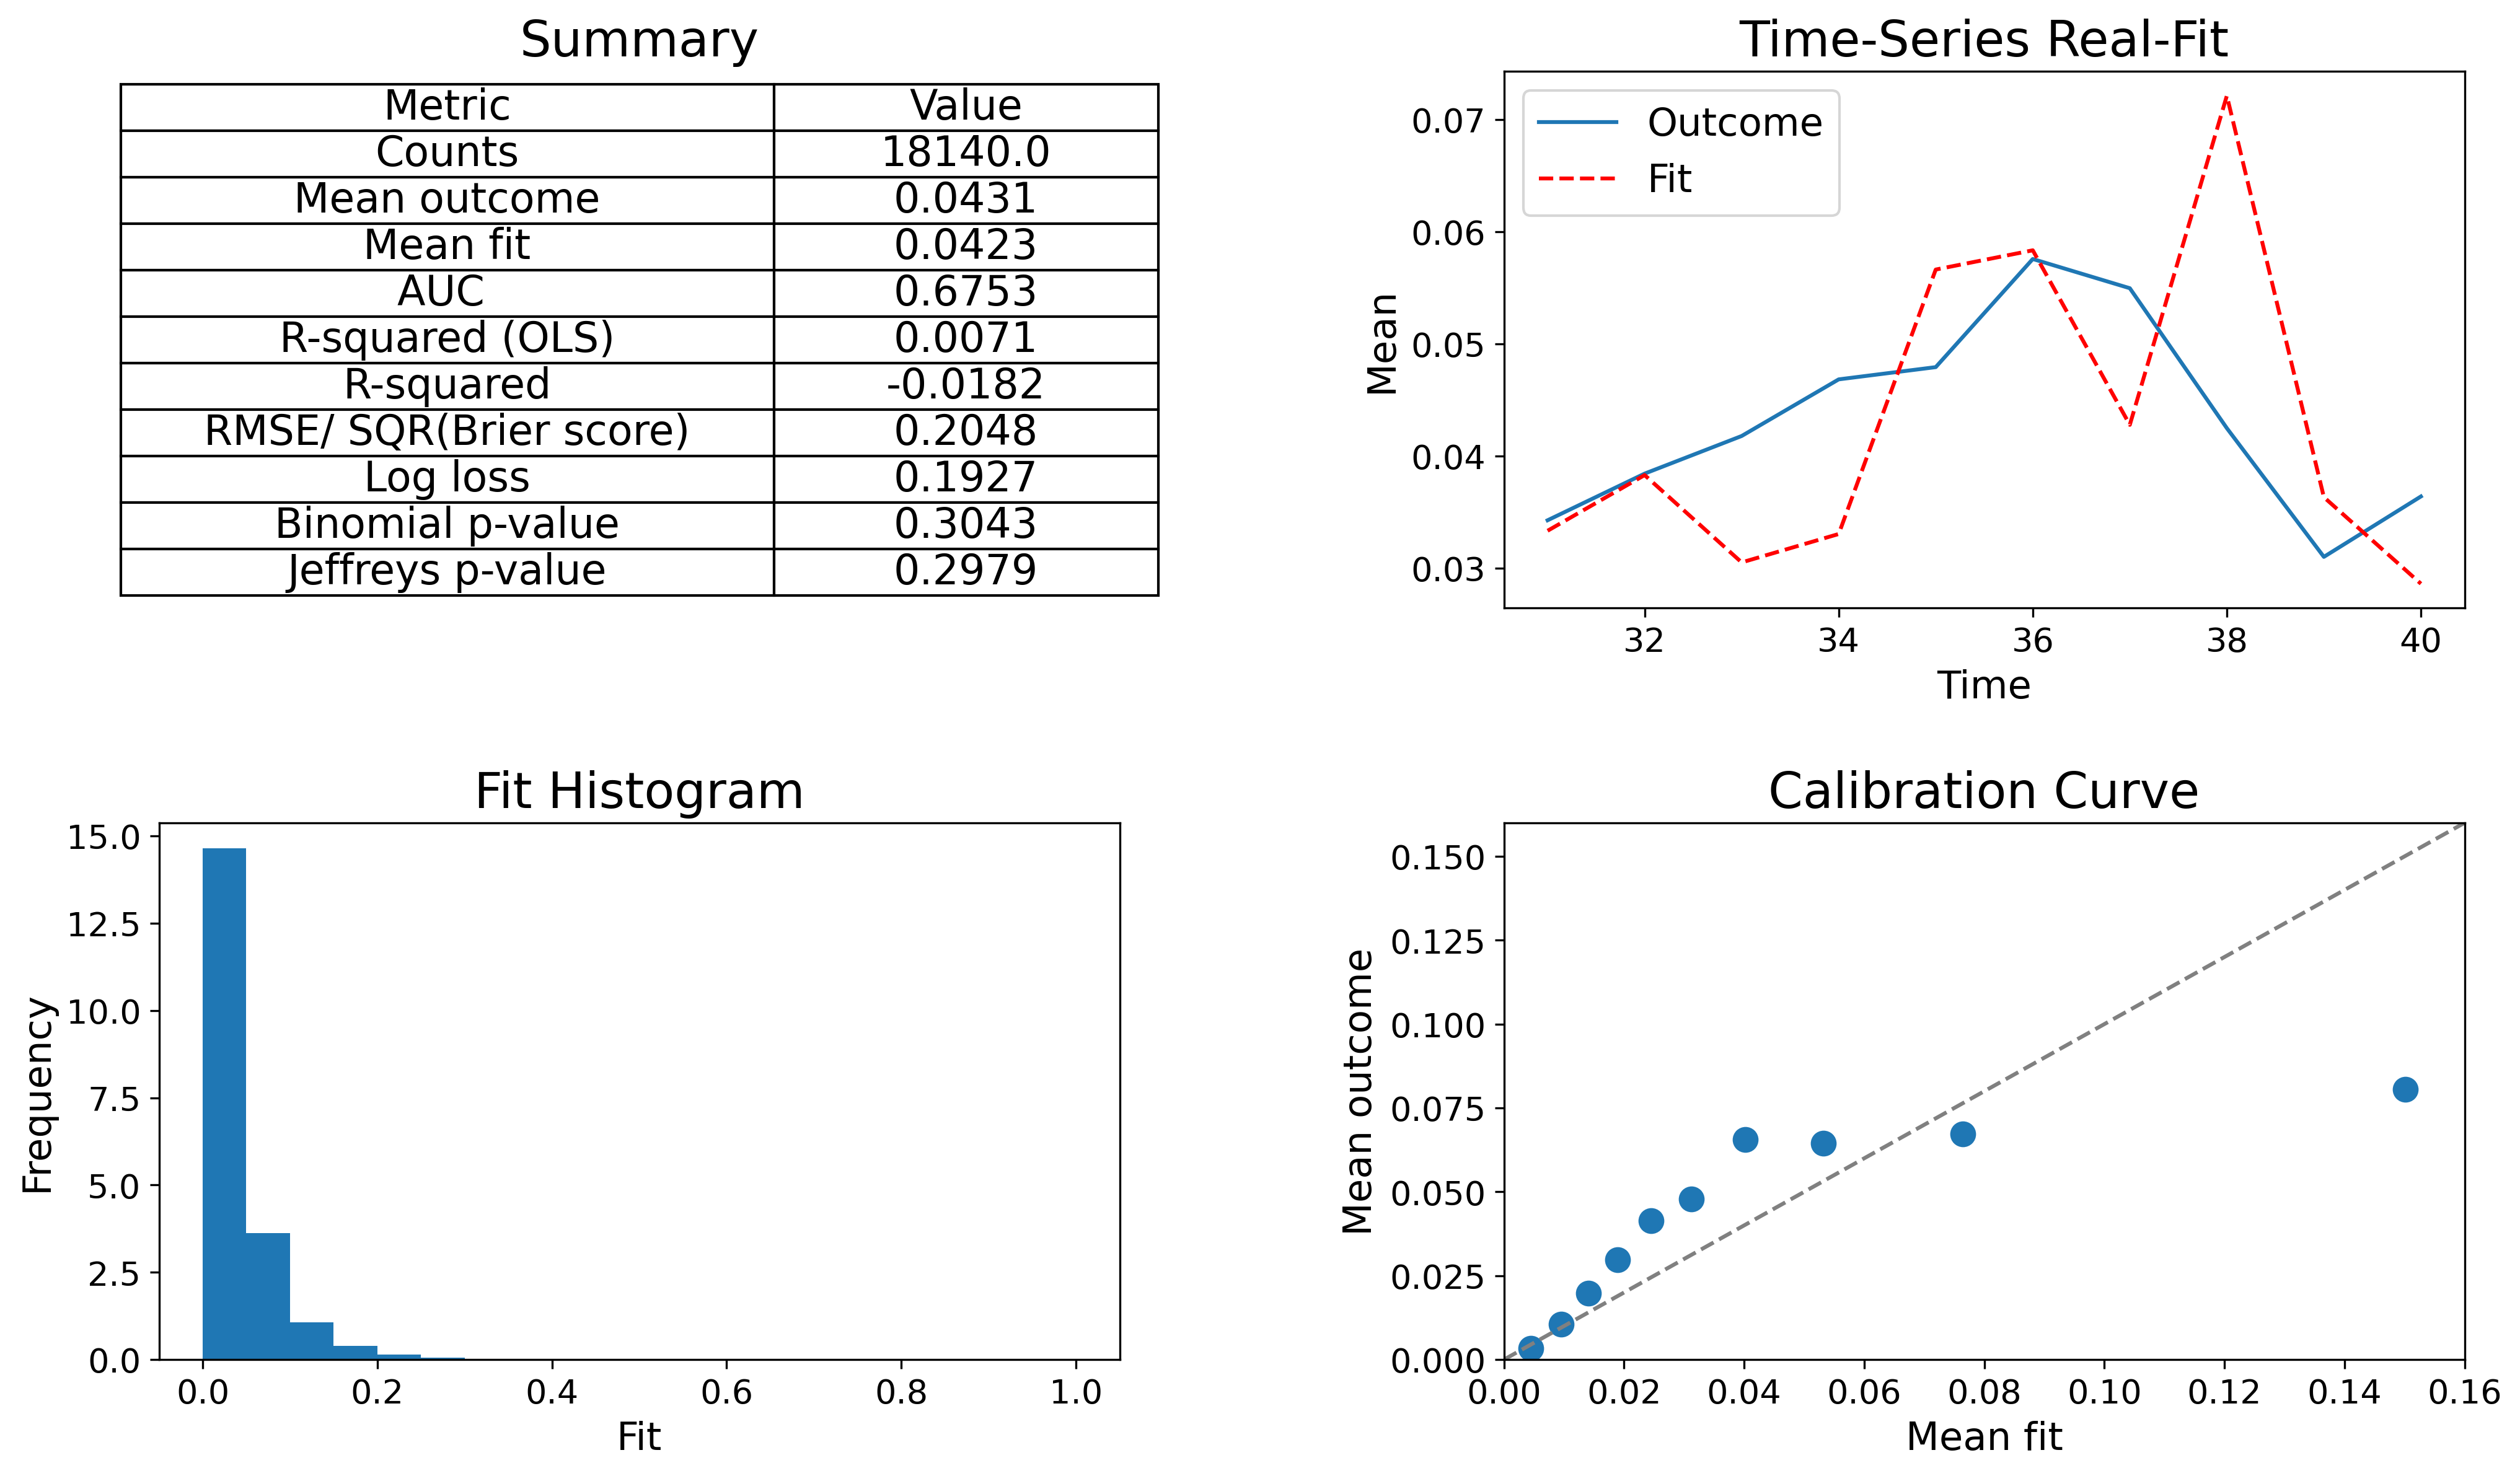

In [49]:
from dcr import *  
data,data_train,data_test,_,_,_,_ = dataprep(data, depvar='default_time', splitvar='time',  threshold=30)  
data_test = data_test.query('time <=40').copy() 
model_lr4_train2 = smf.glm('default_time ~ cep_time + equity_time + interest_rate_time +  FICO_orig_time + gdp_time + PCA1_1 + PCA2_1 + PCA3_1 + PCA4_1 + PCA5_1 + cluster_1',  family = sm.families.Binomial(), data=data_train).fit()  
PD_test = pd.DataFrame(model_lr4_train2.predict(data_test), columns = ['PD_test']) 
PD_test = pd.concat([data_test[['default_time','time']], PD_test],axis=1).dropna() 
validation(PD_test.PD_test, PD_test.default_time, PD_test.time) 